<a href="https://colab.research.google.com/github/HamzaEric/facial-expression-autoencoders/blob/main/Notebooks/VAE_vs_AE_Latent_Space_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib as mpl
from matplotlib.colors import ListedColormap

# Latent Space Interpretation

In the previous notebooks, we focused mainly on **training the VAE** and checking whether it could reconstruct images.

Now we want to look **inside the VAE** and investigate what it actually learned.

Instead of only asking:

> "Can the VAE reconstruct the face?"

we are asking:

> "What does the VAE's latent space look like?"

---

## What is the latent space?

When an image enters the VAE, the encoder converts it into a latent representation.

For our VAE:

```text
48 × 48 image
      ↓
   Encoder
      ↓
   μ (32 values)
      ↓
Latent representation

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn


data = np.load("/content/drive/MyDrive/fer2013_full.npz")
X, y = data["X"], data["y"]

print(f"Dataset loaded: {X.shape[0]} samples, shape {X.shape[1:]}")

# Convert to torch tensor for encoding
X_t = torch.tensor(X, dtype=torch.float32).view(X.shape[0], -1)

device = "cuda" if torch.cuda.is_available() else "cpu"

# --- Define VAE model architecture ---
class VAE(nn.Module):
    def __init__(self, latent_dim=32):
        super(VAE, self).__init__()

        # Encoder
        self.fc1 = nn.Linear(2304, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)

        # Decoder
        self.fc3 = nn.Linear(latent_dim, 128)
        self.fc4 = nn.Linear(128, 512)
        self.fc5 = nn.Linear(512, 2304)

        # Activations
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def encode(self, x):
        h1 = self.relu(self.fc1(x))
        h2 = self.relu(self.fc2(h1))
        mu = self.fc_mu(h2)
        logvar = self.fc_logvar(h2)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = self.relu(self.fc3(z))
        h4 = self.relu(self.fc4(h3))
        return self.sigmoid(self.fc5(h4))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

# --- Load pre-trained model ---
vae_model = VAE(latent_dim=32).to(device)
vae_model.load_state_dict(torch.load("vae_model.pth", map_location=device))
vae_model.eval()
print(" Correct VAE loaded successfully.")

Dataset loaded: 35887 samples, shape (48, 48)
 Correct VAE loaded successfully.


In [4]:
print(device)

cpu


In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_val_t = torch.tensor(X_val, dtype=torch.float32).view(X_val.shape[0], -1)  # (N, 2304)

print(f"✅ Data loaded. Train: {X_train.shape}, Val: {X_val.shape}")

✅ Data loaded. Train: (30503, 48, 48), Val: (5384, 48, 48)


In [7]:
class VAE(nn.Module):
    def __init__(self, latent_dim=32):  # match NB03
        super(VAE, self).__init__()
        # Encoder
        self.fc1 = nn.Linear(2304, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        # Decoder
        self.fc3 = nn.Linear(latent_dim, 128)
        self.fc4 = nn.Linear(128, 512)
        self.fc5 = nn.Linear(512, 2304)
        # Activations
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def encode(self, x):
        h1 = self.relu(self.fc1(x))
        h2 = self.relu(self.fc2(h1))
        mu = self.fc_mu(h2)
        logvar = self.fc_logvar(h2)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = self.relu(self.fc3(z))
        h4 = self.relu(self.fc4(h3))
        return self.sigmoid(self.fc5(h4))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

**Load Trained Models**

In [9]:
vae_model = VAE(latent_dim=32).to(device)
vae_model.load_state_dict(torch.load("vae_model.pth", map_location=device))
vae_model.eval()
print("Loaded trained VAE (latent_dim=32).")


class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(2304, 512),
            nn.ReLU(),
            nn.Linear(512, 128)
        )
        self.decoder = nn.Sequential(
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, 2304),
            nn.Sigmoid()
        )
    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

try:
    ae_model = Autoencoder().to(device)
    ae_model.load_state_dict(torch.load("/content/drive/MyDrive/ae_model.pth", map_location=device))
    ae_model.eval()
    print(" Loaded trained AE.")
except Exception as e:
    print(" AE checkpoint not found; we will proceed with VAE-only analysis.")


Loaded trained VAE (latent_dim=32).
 Loaded trained AE.


### **Encoding Faces into Latent Space**

Now that our trained model and dataset are ready, we will **encode each face image** into its **latent representation** — specifically, its mean vector **μ**.  
These vectors represent how the VAE "understands" the structure of each face in a compressed, abstract form.

**Purpose**

To project the input faces into the latent space learned by the VAE.  
Each face will be represented by its latent mean vector `μ`, which captures its most salient emotional and structural features.

**Encode Validation Faces into Latent Mean Vectors**

In [12]:
vae_model.eval()

all_mu = []
all_labels = []

with torch.no_grad():
    for i in range(0, len(X_val_t), 128):
        batch = X_val_t[i:i+128].to(device)
        mu, logvar = vae_model.encode(batch)
        all_mu.append(mu.cpu())
        all_labels.append(torch.tensor(y_val[i:i+128]))

# Concatenate all batches
mu_all = torch.cat(all_mu)
labels_all = torch.cat(all_labels)

print(f" Encoded {mu_all.shape[0]} faces into latent space.")
print(f"Latent vector shape: {mu_all.shape[1]} dimensions")

 Encoded 5384 faces into latent space.
Latent vector shape: 32 dimensions


In [13]:
for i in range(5):
    print(f"Sample {i} | Emotion label: {labels_all[i].item()} | μ[:5]: {mu_all[i, :5].numpy()}")

Sample 0 | Emotion label: 2 | μ[:5]: [-0.84127843 -3.8146307  -0.04880077  2.4424977  -3.02856   ]
Sample 1 | Emotion label: 3 | μ[:5]: [ 0.639941   -4.9914417  -0.24153224  3.3986397  -4.2634425 ]
Sample 2 | Emotion label: 2 | μ[:5]: [ 0.2212691  -5.589843    0.75561374  3.2099986  -3.7985156 ]
Sample 3 | Emotion label: 4 | μ[:5]: [-0.53870684 -5.841421    0.7597749   3.7627008  -4.702875  ]
Sample 4 | Emotion label: 0 | μ[:5]: [-0.1262019  -1.2712686   0.15306588  0.87259614 -1.1694155 ]


**Reflection**

Each vector μ is a compact summary of an entire facial image.</br>
Unlike the pixel space (48×48 = 2304 dimensions), the latent space (here, 32D) captures conceptual regularities — patterns like smiling, frowning, or surprise — in a continuous form.

These representations will now serve as the foundation for:

- visualizing latent clusters by emotion, and
- interpolating between emotions to explore facial transitions.

> In essence, we’ve transformed high-dimensional pixel data into a “semantic coordinate system” for faces — a psychological space where nearby points correspond to similar expressions.

---

### **Project μ to 2D via PCA or t-SNE**

In [15]:
try:
    mu_all, labels_all
except NameError:
    vae_model.eval()
    all_mu, all_labels = [], []
    with torch.no_grad():
        for i in range(0, len(X_val_t), 128):
            batch = X_val_t[i:i+128].to(device)
            mu, logvar = vae_model.encode(batch)
            all_mu.append(mu.cpu())
            all_labels.append(torch.tensor(y_val[i:i+128]))
    mu_all = torch.cat(all_mu)
    labels_all = torch.cat(all_labels)

Z = mu_all.numpy()
y_vis = labels_all.numpy()

# Choose projection: "pca" (fast) or "tsne" (nonlinear)
PROJECTION = "pca"  # change to "tsne" after confirming PCA works

if PROJECTION == "pca":
    Z2 = PCA(n_components=2, random_state=42).fit_transform(Z)
else:

    Z30 = PCA(n_components=min(30, Z.shape[1]), random_state=42).fit_transform(Z)
    Z2 = TSNE(
        n_components=2, perplexity=30, learning_rate="auto",
        init="pca", random_state=42
    ).fit_transform(Z30)

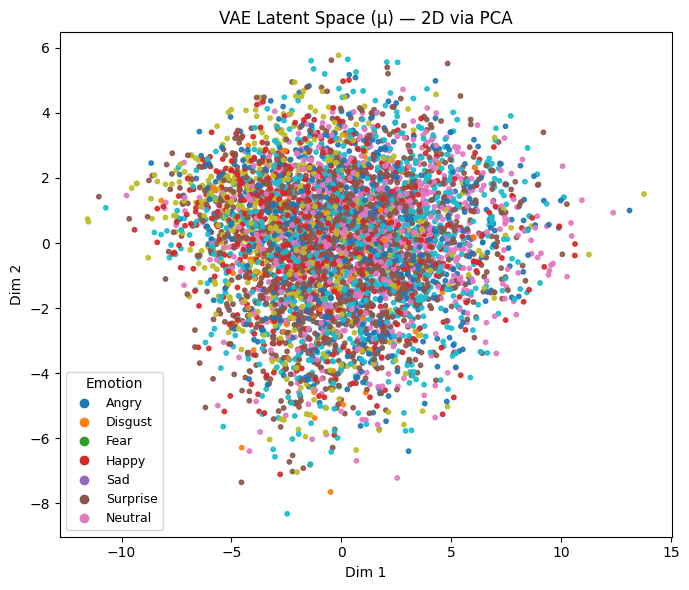

In [16]:
emotions = ["Angry","Disgust","Fear","Happy","Sad","Surprise","Neutral"]

plt.figure(figsize=(7,6))
sc = plt.scatter(Z2[:,0], Z2[:,1], c=y_vis, s=10, cmap="tab10", alpha=0.9)
# Build legend with fixed labels
handles = []
for k, name in enumerate(emotions):
    handles.append(plt.Line2D([], [], marker="o", linestyle="", color=plt.cm.tab10(k/10), label=name))
plt.legend(handles=handles, title="Emotion", loc="best", fontsize=9)
plt.title(f"VAE Latent Space (μ) — 2D via {PROJECTION.upper()}")
plt.xlabel("Dim 1"); plt.ylabel("Dim 2")
plt.tight_layout(); plt.show()

**Interpretation:**
- If the VAE learned meaningful structure, nearby points should reflect similar facial geometry or expression.
- “Happy” often forms a clearer region; “Neutral” overlaps multiple regions, reflecting its mid-position on an emotion continuum.

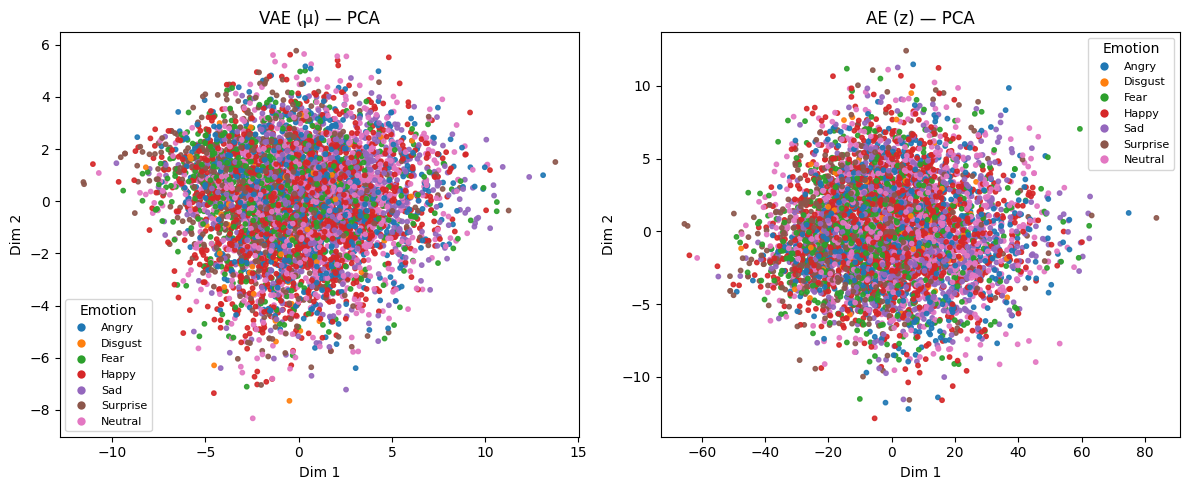

In [18]:
try:
    # Encode with AE
    ae_model.eval()
    zs = []
    with torch.no_grad():
        for i in range(0, len(X_val_t), 128):
            batch = X_val_t[i:i+128].to(device)
            _, z_ae = ae_model(batch)      # our AE forward returns (x_hat, z)
            zs.append(z_ae.cpu())
    Z_AE = torch.cat(zs).numpy()

    # Project AE embeddings with the same method
    if PROJECTION == "pca":
        Z2_AE = PCA(n_components=2, random_state=42).fit_transform(Z_AE)
    else:
        Z30_AE = PCA(n_components=min(30, Z_AE.shape[1]), random_state=42).fit_transform(Z_AE)
        Z2_AE = TSNE(
            n_components=2, perplexity=30, learning_rate="auto",
            init="pca", random_state=42
        ).fit_transform(Z30_AE)

    # --- MINIMAL FIX: discrete cmap + norm + per-axes legends ---

    # discrete colors from tab10, one per class id
    _base = plt.get_cmap("tab10").colors
    _colors = _base[:len(emotions)]
    _cmap = ListedColormap(_colors)
    # each integer label maps to exactly one color
    _norm = mpl.colors.BoundaryNorm(boundaries=np.arange(-0.5, len(emotions)+0.5, 1),
                                    ncolors=len(emotions))

    # Side-by-side figure
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)

    # ---- VAE plot ----
    axes[0].scatter(Z2[:,0], Z2[:,1], c=y_vis, s=10, cmap=_cmap, norm=_norm, alpha=0.9)
    axes[0].set_title(f"VAE (μ) — {PROJECTION.upper()}")
    axes[0].set_xlabel("Dim 1"); axes[0].set_ylabel("Dim 2")
    # per-axes legend using the exact same colors
    handles0 = [plt.Line2D([], [], marker="o", linestyle="", markerfacecolor=_colors[k],
                           markeredgecolor='none', label=emotions[k]) for k in range(len(emotions))]
    axes[0].legend(handles=handles0, title="Emotion", fontsize=8, loc="best")

    # ---- AE plot ----
    axes[1].scatter(Z2_AE[:,0], Z2_AE[:,1], c=y_vis, s=10, cmap=_cmap, norm=_norm, alpha=0.9)
    axes[1].set_title(f"AE (z) — {PROJECTION.upper()}")
    axes[1].set_xlabel("Dim 1"); axes[1].set_ylabel("Dim 2")
    handles1 = [plt.Line2D([], [], marker="o", linestyle="", markerfacecolor=_colors[k],
                           markeredgecolor='none', label=emotions[k]) for k in range(len(emotions))]
    axes[1].legend(handles=handles1, title="Emotion", fontsize=8, loc="best")

    plt.tight_layout()
    plt.show()

except NameError:
    print("AE model not available — skipping AE vs VAE overlay.")


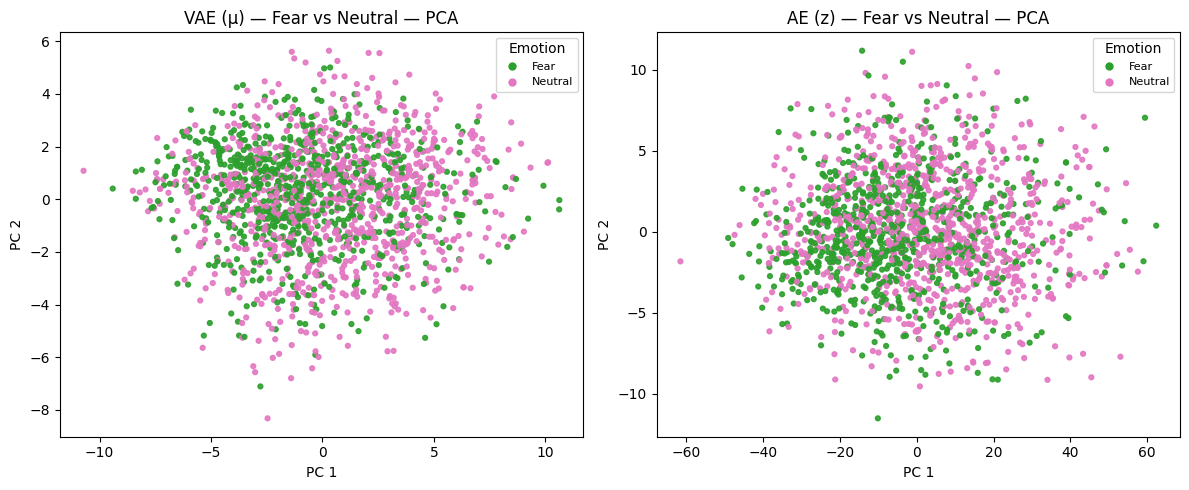

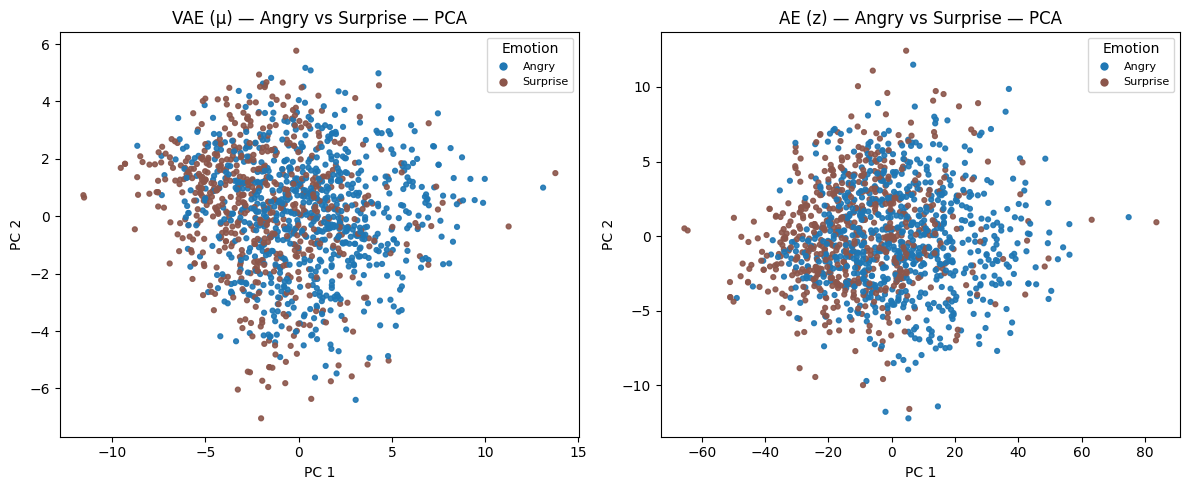

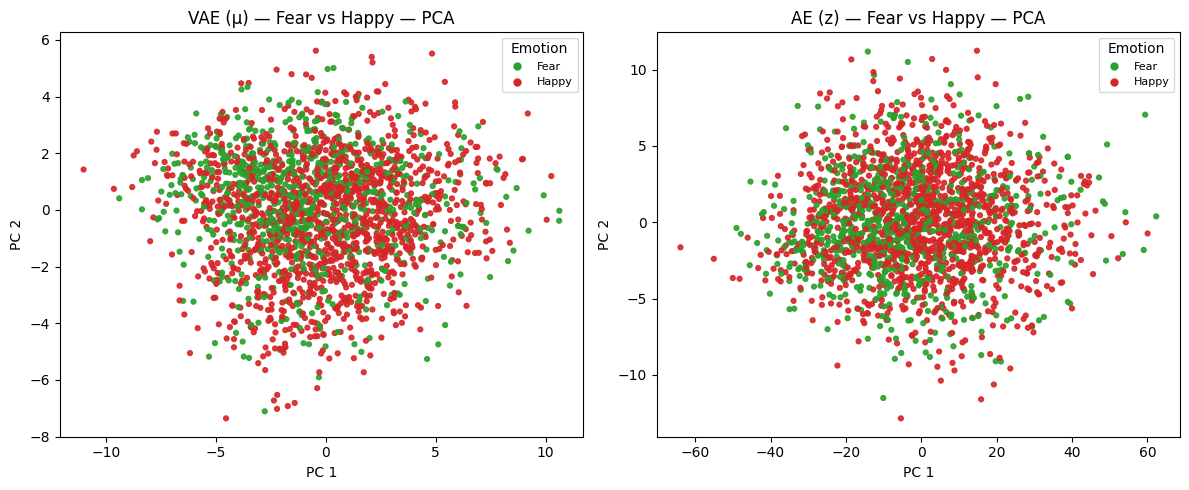

In [19]:
try:
    _cmap, _norm, _colors
except NameError:
    base = plt.get_cmap("tab10").colors
    _colors = base[:len(emotions)]
    _cmap = ListedColormap(_colors)
    _norm = mpl.colors.BoundaryNorm(boundaries=np.arange(-0.5, len(emotions)+0.5, 1),
                                    ncolors=len(emotions))


pairs = [
    (2, 6, "Fear vs Neutral"),  # Fear=2, Neutral=6
    (0, 5, "Angry vs Surprise"),  # Angry=0, Surprise=5
    (2, 3, "Fear vs Happy"),      # Fear=2, Happy
]

for a, b, title in pairs:
    mask = np.isin(y_vis, [a, b])

    # Prepare per-axes legends (only the two classes in this pair)
    handles = [
        plt.Line2D([], [], marker="o", linestyle="",
                   markerfacecolor=_colors[a], markeredgecolor="none",
                   label=emotions[a]),
        plt.Line2D([], [], marker="o", linestyle="",
                   markerfacecolor=_colors[b], markeredgecolor="none",
                   label=emotions[b]),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)

    # VAE (μ) — PCA subset
    axes[0].scatter(Z2[mask, 0], Z2[mask, 1], c=y_vis[mask], s=12, cmap=_cmap, norm=_norm, alpha=0.9)
    axes[0].set_title(f"VAE (μ) — {title} — PCA")
    axes[0].set_xlabel("PC 1"); axes[0].set_ylabel("PC 2")
    axes[0].legend(handles=handles, title="Emotion", fontsize=8, loc="best")

    # AE (z) — PCA subset
    axes[1].scatter(Z2_AE[mask, 0], Z2_AE[mask, 1], c=y_vis[mask], s=12, cmap=_cmap, norm=_norm, alpha=0.9)
    axes[1].set_title(f"AE (z) — {title} — PCA")
    axes[1].set_xlabel("PC 1"); axes[1].set_ylabel("PC 2")
    axes[1].legend(handles=handles, title="Emotion", fontsize=8, loc="best")

    plt.tight_layout()
    plt.show()


**Reflection**

- The VAE’s probabilistic latent space encourages continuity and smooth transitions; clusters are often less fragmented than those from a deterministic AE.
- Overlap between classes is natural: many expressions share facial components and vary along continuous dimensions (e.g., valence, arousal).

### **Latent Space Interpolation (Emotion Morphing)**

Up to this point, we’ve **visualized** how the latent space organizes faces, but now we’ll **travel through it** — literally.  
By interpolating between two latent vectors (representing two different emotions), we can *see* how the VAE transitions smoothly between facial expressions.  
This is one of the most compelling demonstrations of what makes VAEs *generative* rather than just *compressive*.

**Conceptual Intuition**

In classical Autoencoders (AEs), latent vectors don’t necessarily have *semantic continuity*:  
moving a bit in the latent space can cause unpredictable jumps in output, because AEs simply memorize a mapping.  

In contrast, **VAEs enforce a structured latent distribution**, encouraging nearby points in latent space to correspond to similar, meaningful faces.  
This is achieved through the **KL-divergence regularization** that aligns the latent space with a standard Gaussian distribution $ \mathcal{N}(0, I) $.

In [20]:
def get_face_by_emotion(emotion_label, X, y):
    idx = np.where(y == emotion_label)[0][0]
    return X[idx]

# Emotion labels: ["Angry","Disgust","Fear","Happy","Sad","Surprise","Neutral"]
emotion_map = {i: e for i, e in enumerate(["Angry","Disgust","Fear","Happy","Sad","Surprise","Neutral"])}

happy_face = get_face_by_emotion(3, X_val, y_val)  # Happy
fear_face   = get_face_by_emotion(2, X_val, y_val)  # Fear

# Convert to tensors
x_happy = torch.tensor(happy_face, dtype=torch.float32).view(1, -1).to(device)
x_fear   = torch.tensor(fear_face, dtype=torch.float32).view(1, -1).to(device)

# Encode to latent means
vae_model.eval()
with torch.no_grad():
    mu_happy, _ = vae_model.encode(x_happy)
    mu_fear, _   = vae_model.encode(x_fear)

print("Happy μ:", mu_happy.shape, " Sad μ:", mu_fear.shape)

Happy μ: torch.Size([1, 32])  Sad μ: torch.Size([1, 32])


In [21]:
alphas = np.linspace(0, 1, 10)
interpolated_faces = []
vae_model.eval()
with torch.no_grad():
    for a in alphas:
        z = (1 - a) * mu_happy + a * mu_fear
        recon = vae_model.decode(z).cpu().view(48, 48)
        interpolated_faces.append(recon.numpy())

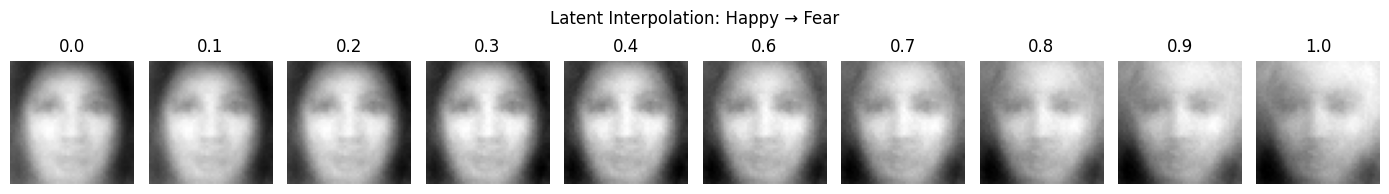

In [22]:
fig, axes = plt.subplots(1, len(interpolated_faces), figsize=(14, 2))
for i, img in enumerate(interpolated_faces):
    axes[i].imshow(img, cmap="gray")
    axes[i].axis("off")
    axes[i].set_title(f"{alphas[i]:.1f}")
plt.suptitle("Latent Interpolation: Happy → Fear", fontsize=12)
plt.tight_layout()
plt.show()

**Reflection**

Let’s interpret what we see:

- **Gradual Morphing:** The face transitions smoothly from happy to fear.
You may notice the smile fading, the eyes drooping, and facial features subtly shifting — without abrupt jumps.

- **Continuous Representation:** This smoothness arises because the latent space was trained to resemble a continuous probability distribution.
That’s the core achievement of the VAE — it **learns a manifold** where emotional and geometric features blend naturally.

- **Psychological Resonance:** Emotion in humans isn’t binary — we move fluidly along continua of valence and arousal.
The VAE’s latent space

**AE Comparison**

To emphasize the benefit of probabilistic latent structure, we can repeat the interpolation using the AE

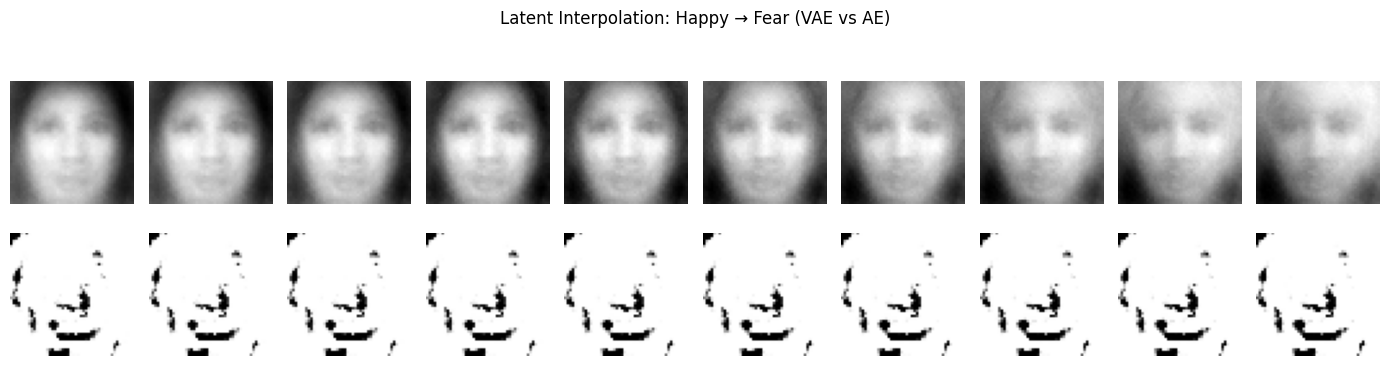

In [23]:
try:
    ae_model.eval()
    with torch.no_grad():
        z_happy = ae_model.encoder(x_happy)
        z_fear = ae_model.encoder(x_fear)
        ae_interpolations = []
        for a in alphas:
            z = (1 - a) * z_happy + a * z_fear
            recon = ae_model.decoder(z).cpu().view(48, 48)
            ae_interpolations.append(recon.numpy())

    fig, axes = plt.subplots(2, len(alphas), figsize=(14, 4))
    for i, img in enumerate(interpolated_faces):
        axes[0, i].imshow(img, cmap="gray"); axes[0, i].axis("off")
    for i, img in enumerate(ae_interpolations):
        axes[1, i].imshow(img, cmap="gray"); axes[1, i].axis("off")
    axes[0, 0].set_ylabel("VAE", rotation=0, labelpad=20)
    axes[1, 0].set_ylabel("AE", rotation=0, labelpad=20)
    plt.suptitle("Latent Interpolation: Happy → Fear (VAE vs AE)", fontsize=12)
    plt.tight_layout()
    plt.show()

except NameError:
    print("AE model not loaded; skipping comparison.")



### **6. Comparing AE vs. VAE Representations**

Having explored how the **VAE organizes and interpolates emotions**, we now step back to compare it with the **Autoencoder (AE)**.  
Both models compress faces into lower-dimensional latent vectors — but the *structure* and *semantics* of these spaces differ profoundly.


**Conceptual Motivation**

| Aspect | Autoencoder (AE) | Variational Autoencoder (VAE) |
|:-------|:------------------|:-------------------------------|
| Latent representation | Deterministic vector $ z = f(x) $ | Probabilistic distribution $ z \sim \mathcal{N}(\mu, \sigma^2) $ |
| Structure | Scattered, unstructured embeddings | Continuous, Gaussian-like manifold |
| Interpolation | Often abrupt or implausible | Smooth and semantically coherent |
| Generativity | Poor — cannot easily sample new faces | Excellent — sampling from latent prior works well |

In [24]:
vae_model.eval()
try:
    ae_model.eval()
except NameError:
    ae_model = None

# Compute latent representations for both AE and VAE
vae_latents = []
ae_latents = []

with torch.no_grad():
    for i in range(0, len(X_val_t), 128):
        xb = X_val_t[i:i+128].to(device)
        mu, _ = vae_model.encode(xb)
        vae_latents.append(mu.cpu())
        if ae_model:
            _, z = ae_model(xb)
            ae_latents.append(z.cpu())

vae_latents = torch.cat(vae_latents).numpy()
if ae_model:
    ae_latents = torch.cat(ae_latents).numpy()

# Compute statistics
print(f"VAE latent mean: {vae_latents.mean():.4f}, std: {vae_latents.std():.4f}")
if ae_model:
    print(f"AE latent mean: {ae_latents.mean():.4f}, std: {ae_latents.std():.4f}")

VAE latent mean: -0.6776, std: 2.4877
AE latent mean: -2.9614, std: 6.4383


**Visualizing Latent Distributions**

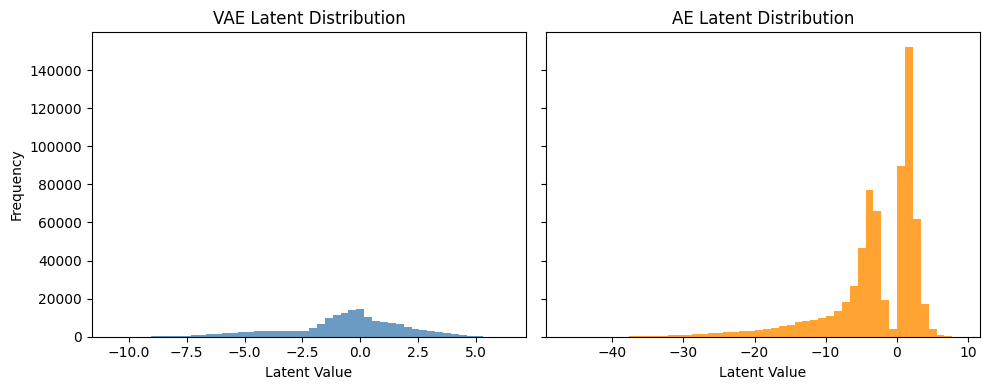

In [25]:
fig, axes = plt.subplots(1, 2 if ae_model else 1, figsize=(10, 4), sharey=True)
axes = np.atleast_1d(axes)

axes[0].hist(vae_latents.flatten(), bins=50, color="steelblue", alpha=0.8)
axes[0].set_title("VAE Latent Distribution")
axes[0].set_xlabel("Latent Value"); axes[0].set_ylabel("Frequency")

if ae_model:
    axes[1].hist(ae_latents.flatten(), bins=50, color="darkorange", alpha=0.8)
    axes[1].set_title("AE Latent Distribution")
    axes[1].set_xlabel("Latent Value")

plt.tight_layout()
plt.show()


**Interpretation:**

- The **VAE histogram** should resemble a smooth bell curve (Gaussian-like).
This means the model has learned a continuous, well-behaved latent prior.

- The **AE histogram** (if available) often looks irregular or multimodal, with clumps or gaps — indicating that latent points aren’t evenly distributed, making interpolation or sampling difficult.

## Reflection

- The **AE latent space** is like a messy drawer: you can find what you stored, but nearby items aren’t necessarily related.
- The **VAE latent space** is like an organized library: nearby books (points) share topics — in this case, facial features and emotional tone.

This structured latent space is what empowers VAEs to:

- **interpolate** between emotions smoothly,
- **generate** new, realistic faces by random sampling,
- and **encode** nuanced affective states in a psychologically meaningful way.

The contrast between AE and VAE beautifully illustrates how adding **probabilistic structure** transforms a simple compression model into a **powerful generative system** — one that not only stores but understands patterns in the data.

---

| Concept                                    | What It Does                                       | Why It Matters                                      |
| ------------------------------------------ | -------------------------------------------------- | --------------------------------------------------- |
| **Autoencoder (AE)**                       | Learns compressed representation by reconstruction | Captures structure but no explicit regularization   |
| **Variational Autoencoder (VAE)**          | Learns latent distribution + reconstruction        | Enables smooth latent space + generative ability    |
| **KL Divergence Term**                     | Forces latent distribution toward Gaussian         | Improves continuity & interpolation                 |
| **Reconstruction Loss (MSE/BCE)**          | Measures pixel-level accuracy                      | Indicates how faithfully inputs are rebuilt         |
| **Latent Space Visualization (PCA/t-SNE)** | Projects embeddings to 2D                          | Reveals clustering / semantic structure             |
| **Interpolation in Latent Space**          | Blends between emotions                            | Tests smoothness and continuity of latent space     |
| **AE vs VAE Comparison**                   | AE = accurate recon; VAE = organized latent        | Shows trade-off between reconstruction vs structure |
| **Regularization Effects**                 | VAE adds KL; AE has none by default                | Impacts generalization and representation quality   |
| **Semantic Organization**                  | Clustering of similar emotions                     | Important for downstream classification / meaning   |
